In [ ]:
%pip install pandas matplotlib scikit-learn

mambajs 0.21.4

Process pip requirements ...



Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [1]:
!mamba install pandas matplotlib scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 6.895 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.9      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.24.0     pyhcf101f3_0         conda-forge
+ pandas              3.0.4      np23py313h1e705a5_0  emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.3     pyhd8ed1ab_0         conda-forge
+ requests          

In [2]:
pip install pandas matplotlib scikit-learn

mambajs 0.21.4

Process pip requirements ...

Requirement pandas already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement scikit-learn already handled by conda/micromamba/mamba.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("drug_consumption.csv")

print("Dataset Loaded Successfully!\n")

df.head()

Dataset Loaded Successfully!



,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1885, 32)

Columns:
Index(['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS', 'Alcohol',
       'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack',
       'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms',
       'Nicotine', 'Semer', 'VSA'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1885 non-null   int64  
 1   Age        1885 non-null   float64
 2   Gender     1885 non-null   float64
 3   Education  1885 non-null   float64
 4   Country    1885 non-null   float64
 5   Ethnicity  1885 non-null   float64
 6   Nscore     1885 non-null   float64
 7   Escore     1885 non-null   float64
 8   Oscore     1885 non-null   float64
 9   Ascore     1885 non-null   float64
 10  Cscore   

In [8]:
print(df["Nicotine"].value_counts())

Nicotine
6    610
0    428
2    204
1    193
3    185
5    157
4    108
Name: count, dtype: int64


In [9]:
encoder = LabelEncoder()

df["Nicotine"] = encoder.fit_transform(df["Nicotine"])

In [10]:
X = df[[
    "Age",
    "Gender",
    "Education",
    "Nscore",
    "Escore",
    "Oscore",
    "Ascore",
    "Cscore",
    "Impulsive",
    "SS"
]]

y = df["Nicotine"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1508, 10)
Testing Data: (377, 10)


In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.376657824933687


In [16]:
print(classification_report(y_test, y_pred))

/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.35      0.48      0.41        91
           1       0.32      0.21      0.25        34
           2       0.00      0.00      0.00        44
           3       0.00      0.00      0.00        33
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        34
           6       0.40      0.75      0.52       122

    accuracy                           0.38       377
   macro avg       0.15      0.21      0.17       377
weighted avg       0.24      0.38      0.29       377



In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[44 11  0  0  0  0 36]
 [16  7  0  0  0  0 11]
 [19  0  0  1  0  0 24]
 [ 9  0  0  0  0  0 24]
 [ 3  0  0  1  0  0 15]
 [ 8  0  0  0  0  0 26]
 [25  4  0  1  0  1 91]]


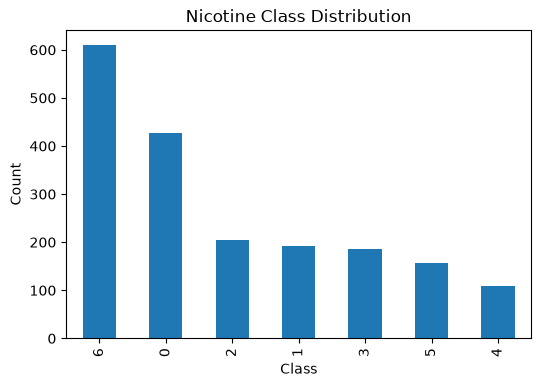

In [18]:
plt.figure(figsize=(6,4))

df["Nicotine"].value_counts().plot(kind="bar")

plt.title("Nicotine Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

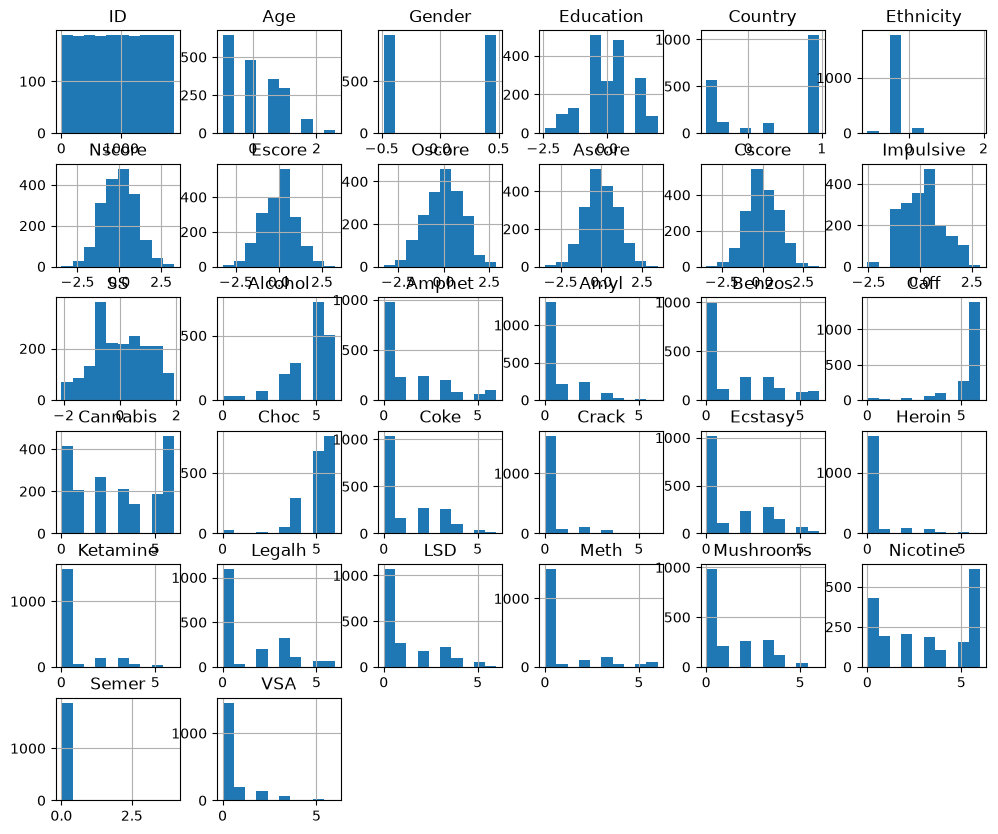

In [21]:
df.hist(figsize=(12,10))
plt.show()

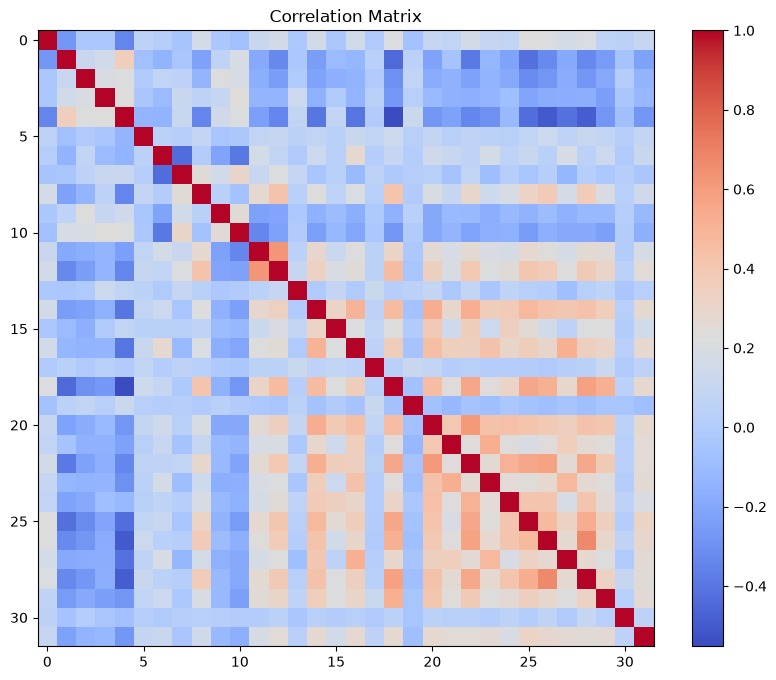

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(df.corr(numeric_only=True), cmap="coolwarm")

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

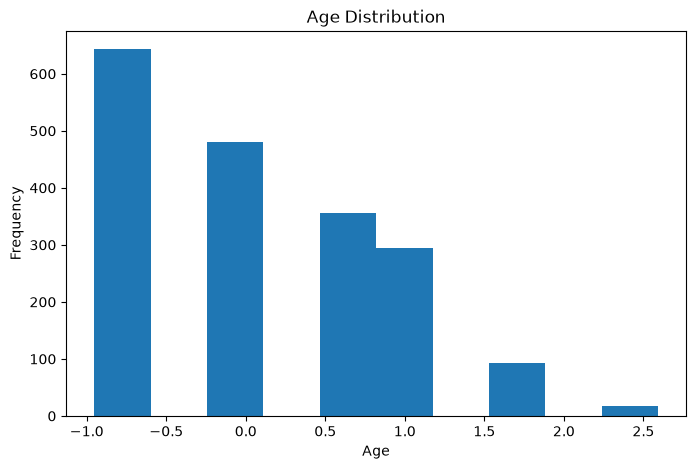

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

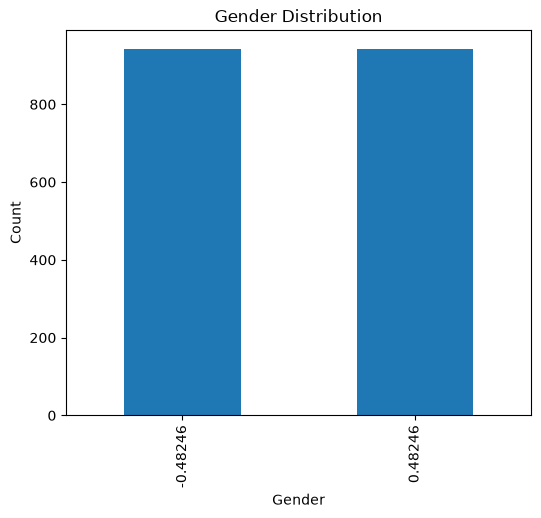

In [24]:
plt.figure(figsize=(6,5))

df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

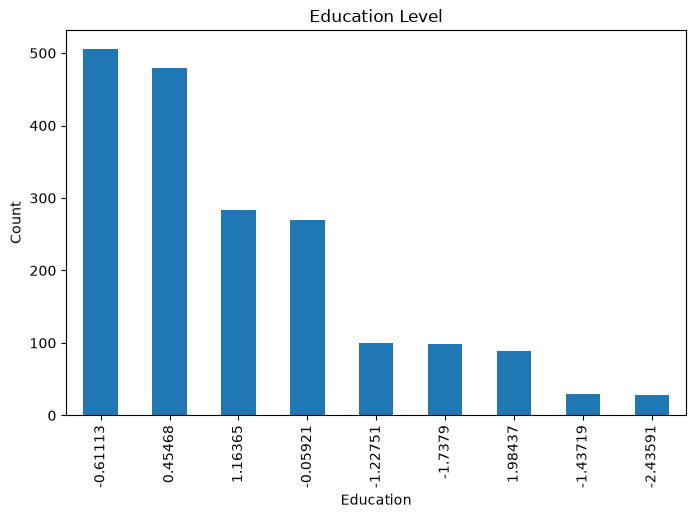

In [26]:
plt.figure(figsize=(8,5))

df["Education"].value_counts().plot(kind="bar")

plt.title("Education Level")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

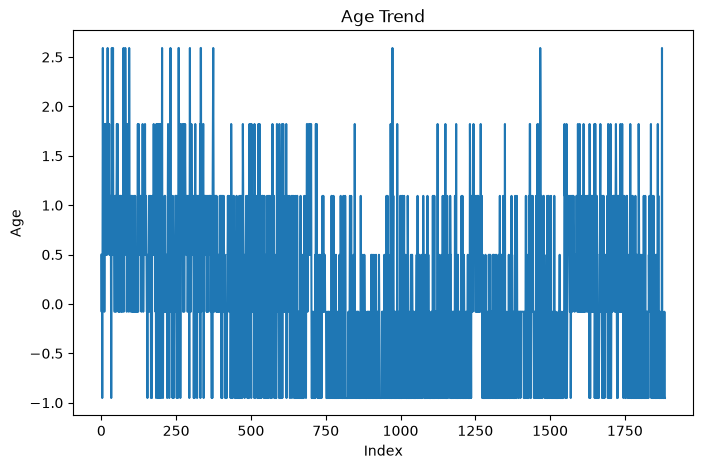

In [27]:
plt.figure(figsize=(8,5))

plt.plot(df["Age"])

plt.title("Age Trend")

plt.xlabel("Index")
plt.ylabel("Age")

plt.show()

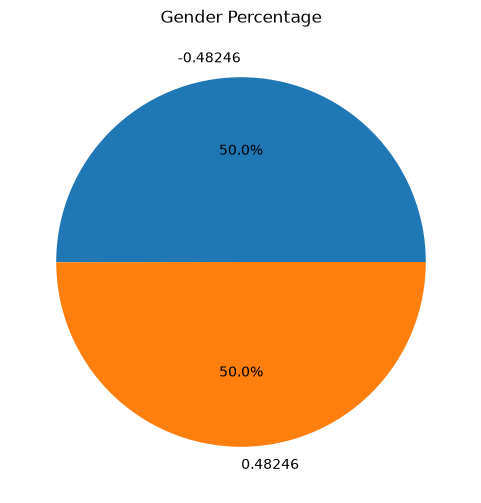

In [28]:
plt.figure(figsize=(6,6))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Percentage")

plt.show()

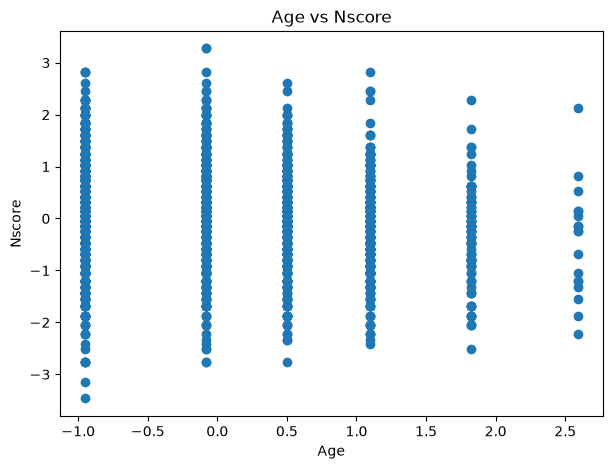

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(df["Age"], df["Nscore"])

plt.xlabel("Age")
plt.ylabel("Nscore")

plt.title("Age vs Nscore")

plt.show()

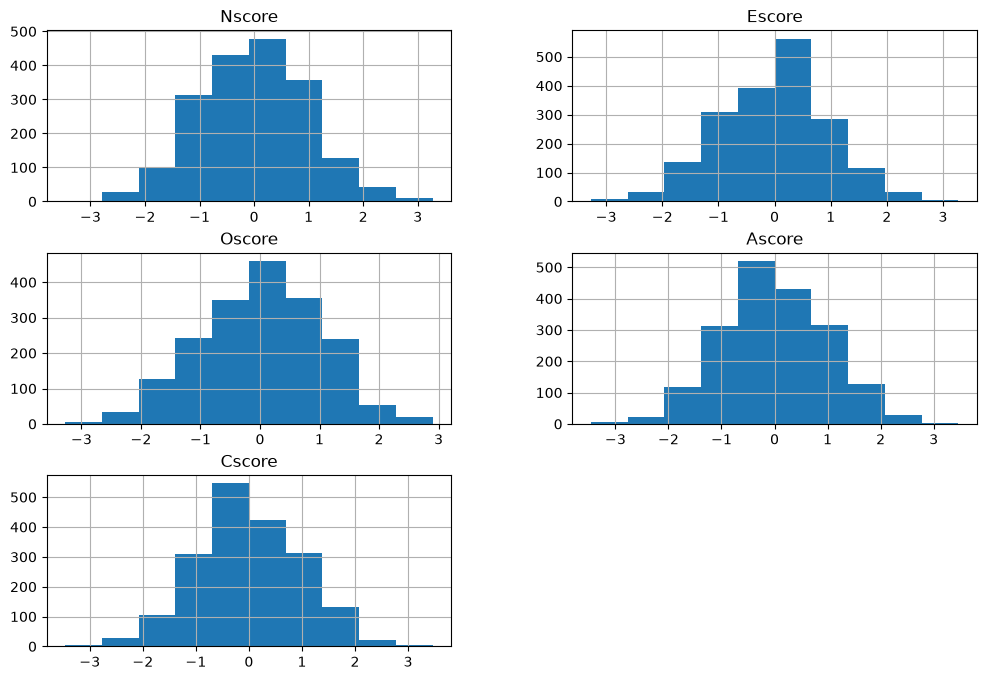

In [31]:
df[[
    "Nscore",
    "Escore",
    "Oscore",
    "Ascore",
    "Cscore"
]].hist(figsize=(12,8))

plt.show()

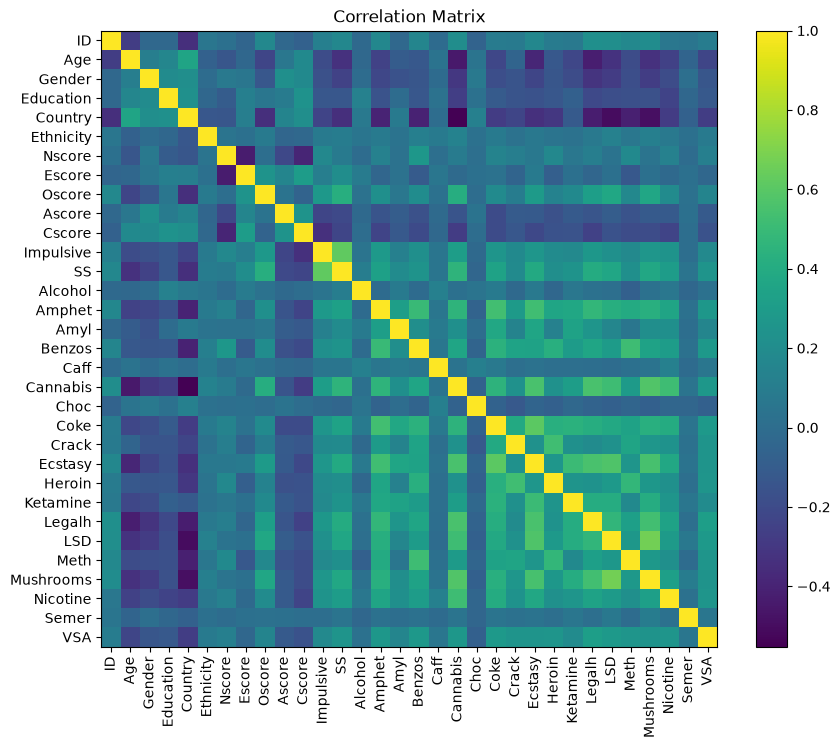

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

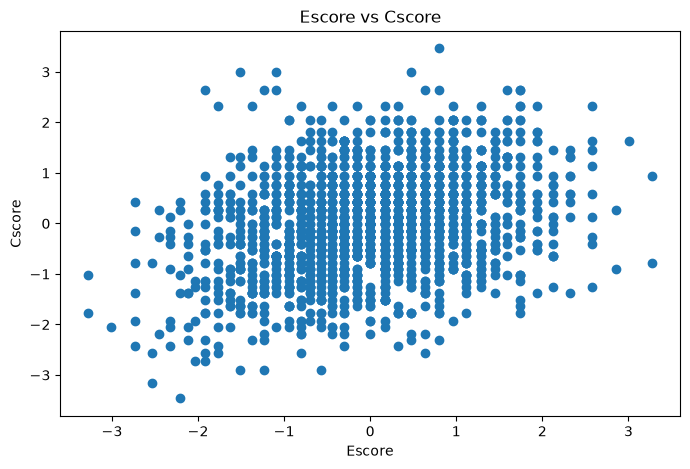

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Escore"],
    df["Cscore"]
)

plt.xlabel("Escore")
plt.ylabel("Cscore")

plt.title("Escore vs Cscore")

plt.show()

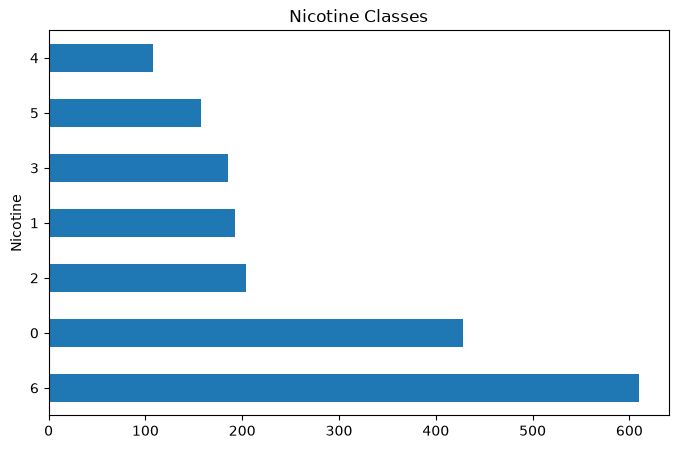

In [34]:
df["Nicotine"].value_counts().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Nicotine Classes")

plt.show()

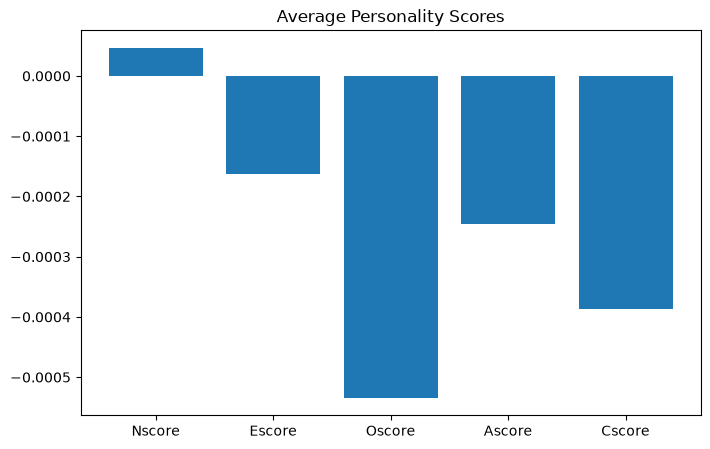

In [35]:
scores = [
    df["Nscore"].mean(),
    df["Escore"].mean(),
    df["Oscore"].mean(),
    df["Ascore"].mean(),
    df["Cscore"].mean()
]

labels = [
    "Nscore",
    "Escore",
    "Oscore",
    "Ascore",
    "Cscore"
]

plt.figure(figsize=(8,5))

plt.bar(labels, scores)

plt.title("Average Personality Scores")

plt.show()

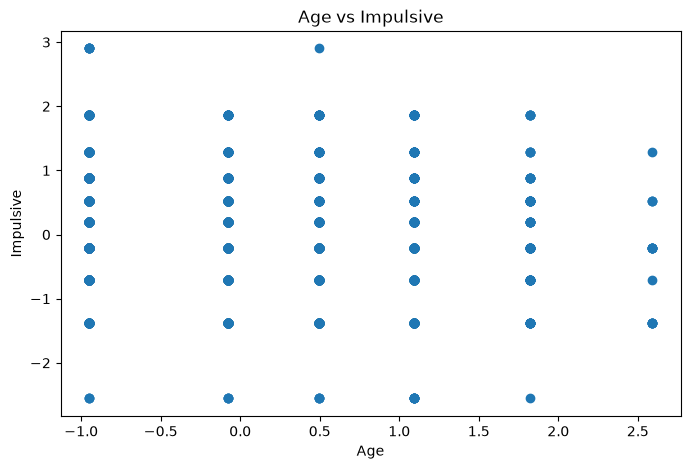

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Age"],
    df["Impulsive"]
)

plt.title("Age vs Impulsive")

plt.xlabel("Age")
plt.ylabel("Impulsive")

plt.show()